<a href="https://colab.research.google.com/github/ada06052005/Analytical_Study_of_Water_Pollution_Across_Multiple_Water_Bodies/blob/main/Tank_wetland.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("/content/Tankxyz.csv")
df

,Type Water Body,State Name,Mean(Temp),Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform),Year,WQI
0,TANK,ANDHRA \nPRADESH,24.00,7.15,7.60,844.5,2.65,1.720,727.5,2022,68
1,TANK,ANDHRA \nPRADESH,25.50,5.75,7.45,349.0,1.50,1.720,619.0,2022,56
2,TANK,ANDHRA \nPRADESH,19.00,6.85,7.90,1134.0,2.70,2.455,400.0,2022,66
3,TANK,KARNATAKA,23.00,4.90,7.60,1030.0,4.10,0.450,3050.0,2022,74
4,TANK,KARNATAKA,25.00,4.75,7.40,1240.0,8.50,11.420,28750.0,2022,266
...,...,...,...,...,...,...,...,...,...,...,...
576,TANK,TELANGANA,26.50,6.85,7.95,2980.0,9.40,32.450,73.0,2018,78
577,TANK,TELANGANA,26.50,3.65,7.95,1114.5,14.00,8.750,274.5,2018,53
578,TANK,TELANGANA,27.50,3.50,7.35,1126.0,16.00,6.450,281.0,2018,51
579,TANK,TELANGANA,27.25,3.35,7.65,1417.5,12.00,1.500,256.5,2018,50


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581 entries, 0 to 580
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Type Water Body       581 non-null    object 
 1   State Name            581 non-null    object 
 2   Mean(Temp)            581 non-null    float64
 3   Mean (DO)             581 non-null    float64
 4   Mean(pH)              581 non-null    float64
 5   Mean conductivity)    581 non-null    float64
 6   Mean(BOD)             581 non-null    float64
 7   Mean Nitrite)         581 non-null    float64
 8   Mean(total coliform)  581 non-null    float64
 9   Year                  581 non-null    int64  
 10  WQI                   581 non-null    int64  
dtypes: float64(7), int64(2), object(2)
memory usage: 50.1+ KB


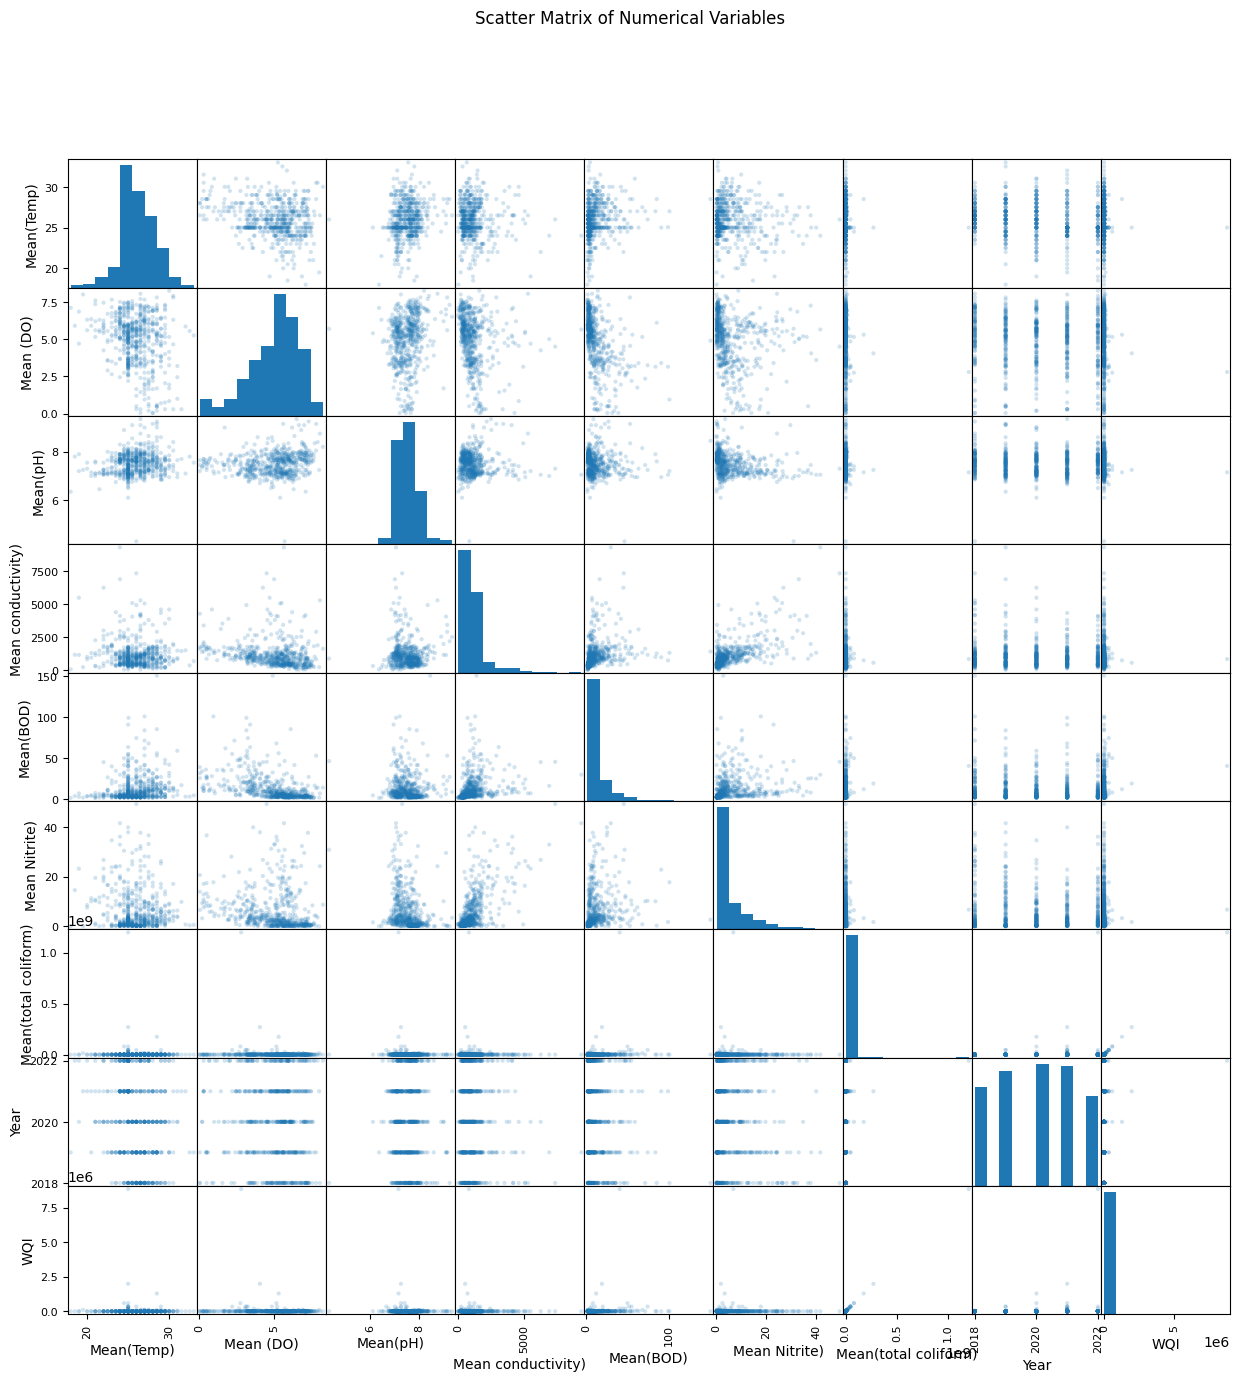

,Mean(Temp),Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform),Year,WQI
count,581.000000,581.000000,581.000000,581.000000,581.000000,581.000000,5.810000e+02,581.000000,5.810000e+02
mean,25.942255,4.996213,7.507401,1135.502582,12.385508,5.941188,4.250970e+06,2019.979346,3.134386e+04
std,2.117487,1.676283,0.459475,1021.213992,15.546133,7.829913,5.192360e+07,1.347892,3.821576e+05
min,18.000000,0.050000,4.300000,18.500000,1.350000,0.025000,1.800000e+01,2018.000000,3.400000e+01
25%,25.000000,3.900000,7.150000,510.000000,3.450000,0.800000,4.200000e+02,2019.000000,6.300000e+01
50%,26.000000,5.300000,7.550000,898.500000,6.500000,2.745000,2.539315e+03,2020.000000,7.600000e+01
75%,27.000000,6.150000,7.750000,1322.500000,15.000000,8.300000,1.755500e+05,2021.000000,1.351000e+03
max,33.000000,8.250000,9.350000,9335.000000,150.750000,49.400000,1.200001e+09,2022.000000,8.832064e+06


In [ ]:
import matplotlib.pyplot as plt

# Summarize numerical data to review key statistics
numerical_summary = df.describe()

# Plot pairwise relationships to check for linear trends with the target variable (WQI)
pd.plotting.scatter_matrix(df.select_dtypes(include=['float64', 'int64']), alpha=0.2, figsize=(15, 15), diagonal='hist')
plt.suptitle("Scatter Matrix of Numerical Variables")
plt.show()

numerical_summary

In [ ]:
from sklearn.preprocessing import StandardScaler

# Selecting numerical predictors and the target variable
predictor_columns = [ 'Mean (DO)', 'Mean(pH)', 'Mean conductivity)',
                     'Mean(BOD)', 'Mean Nitrite)' , 'Mean(total coliform)']
target_column = 'WQI'

# Extract predictors and target
X = df[predictor_columns]
y = df[target_column]

# Scaling predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled predictors back to a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=predictor_columns)

# Display first few rows of scaled data
X_scaled_df.head()


,Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform)
0,1.285966,0.201706,-0.285203,-0.626773,-0.539575,-0.081926
1,0.450065,-0.125035,-0.770828,-0.700810,-0.539575,-0.081928
2,1.106844,0.855187,-0.001473,-0.623554,-0.445623,-0.081933
3,-0.057446,0.201706,-0.103400,-0.533422,-0.701913,-0.081881
4,-0.147007,-0.233949,0.102415,-0.250149,0.700331,-0.081386


In [ ]:
import statsmodels.api as sm

# Add a constant to the predictors for the regression model
X_with_const = sm.add_constant(X_scaled)

# Fit the regression model
model = sm.OLS(y, X_with_const).fit()

# Summarize the regression results
model_summary = model.summary()
model_summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    WQI   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.592e+14
Date:                Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                        14:58:32   Log-Likelihood:                -117.14
No. Observations:                 581   AIC:                             248.3
Df Residuals:                     574   BIC:                             278.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.134e+04      0.012   2.54e+06      0.000    3.13e+04    3.13e+04
x1             9.8593      0.014    702.346      0.000       9.832       9.887
x2             0.9347      0.013     69.986      0.000       0.908       0.961
x3             5.0111      0.017    296.923      0.000       4.978       5.044
x4             7.6295      0.014    543.214      0.000       7.602       7.657
x5             0.4613      0.017     26.666      0.000       0.427       0.495
x6          3.818e+05      0.012   3.06e+07      0.000    3.82e+05    3.82e+05
==============================================================================
Omnibus:                      500.554   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               36.926
Skew:                          -0.018   Prob(JB):                     9.59e-09
Kurtosis:                       1.765   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Variable"] = predictor_columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

vif_data


,Variable,VIF
0,Mean (DO),1.290796
1,Mean(pH),1.168343
2,Mean conductivity),1.865724
3,Mean(BOD),1.292162
4,Mean Nitrite),1.960644
5,Mean(total coliform),1.016722


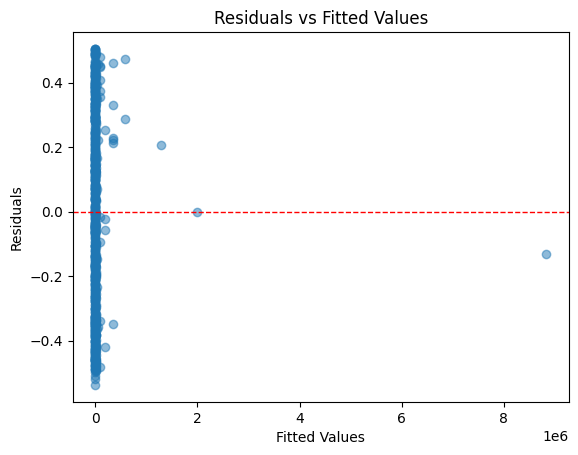

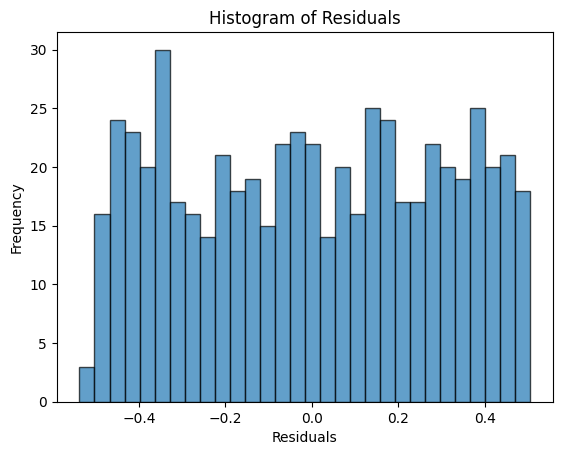

(ShapiroResult(statistic=0.9505603660528026, pvalue=4.97726398407211e-13),
 NormaltestResult(statistic=500.55360093905506, pvalue=2.0237954151063808e-109))

In [ ]:
import numpy as np

# Extract residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

# Plot residuals vs fitted values to check homoscedasticity
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Plot histogram of residuals to check normality
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Perform statistical tests for normality
from scipy.stats import shapiro, normaltest

shapiro_test = shapiro(residuals)
normal_test = normaltest(residuals)

shapiro_test, normal_test


In [ ]:
# Calculate skewness for each predictor and the target variable
skewness = df[predictor_columns + [target_column]].skew()

# Select variables with high skewness (absolute skewness > 1)
high_skew_vars = skewness[abs(skewness) > 1].index.tolist()
skewness


,0
Mean (DO),-0.823686
Mean(pH),0.072007
Mean conductivity),3.111152
Mean(BOD),3.390168
Mean Nitrite),2.167580
Mean(total coliform),21.439724
WQI,21.439720


In [ ]:
# Apply log transformation to highly skewed variables (adding 1 to avoid log(0))
transformed_df = df.copy()
for col in high_skew_vars:
    transformed_df[col] = np.log1p(transformed_df[col])

# Scale predictors after transformation
X_transformed = transformed_df[predictor_columns]
y_transformed = transformed_df[target_column]
X_scaled_transformed = scaler.fit_transform(X_transformed)

# Add constant for regression
X_transformed_const = sm.add_constant(X_scaled_transformed)

# Fit the regression model with transformed data
model_transformed = sm.OLS(y_transformed, X_transformed_const).fit()

# Summarize the transformed regression results
transformed_model_summary = model_transformed.summary()
transformed_model_summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    WQI   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     853.9
Date:                Thu, 05 Dec 2024   Prob (F-statistic):          2.84e-282
Time:                        14:59:26   Log-Likelihood:                -646.67
No. Observations:                 581   AIC:                             1307.
Df Residuals:                     574   BIC:                             1338.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.6979      0.031    185.364      0.000       5.637       5.758
x1             0.2322      0.038      6.045      0.000       0.157       0.308
x2            -0.1554      0.036     -4.337      0.000      -0.226      -0.085
x3            -0.0400      0.044     -0.908      0.364      -0.126       0.046
x4             0.1664      0.048      3.449      0.001       0.072       0.261
x5             0.2574      0.046      5.552      0.000       0.166       0.348
x6             2.1211      0.037     56.926      0.000       2.048       2.194
==============================================================================
Omnibus:                       62.540   Durbin-Watson:                   1.528
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               81.558
Skew:                           0.835   Prob(JB):                     1.95e-18
Kurtosis:                       3.763   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Example input for prediction
new_data = pd.DataFrame({
    'Mean (DO)': [5],
    'Mean(pH)': [7.4],
    'Mean conductivity)': [813],
    'Mean(BOD)': [7],
    'Mean Nitrite)': [2.4],
    'Mean(total coliform)': [1600]
})

# Apply log transformations to predictors
for col in ['Mean conductivity)', 'Mean(BOD)', 'Mean Nitrite)',
            'Mean(total coliform)']:
    new_data[col] = np.log1p(new_data[col])

# Scale the predictors
new_scaled = scaler.transform(new_data)

# Add constant for prediction - Correcting the use of sm.add_constant
new_with_const = sm.add_constant(new_scaled, has_constant='add')

# Predict WQI using the transformed model - Using the correct model name
predicted_wqi = model_transformed.predict(new_with_const) # log_transformed_model should be model_transformed

# Reverse transformation for WQI if needed
predicted_wqi_original_scale = np.expm1(predicted_wqi)
print(predicted_wqi_original_scale)

[119.83680572]


In [ ]:
import pandas as pd
df=pd.read_csv("/content/Wetland.csv")
df

,Type Water Body,State Name,Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform),Year,WQI
0,WETLAND,ANDHRA \nPRADESH,5.85,7.75,615.0,1.75,0.555,658.5,2022,59
1,WETLAND,ANDHRA \nPRADESH,7.00,7.85,363.5,2.20,1.485,152.0,2022,61
2,WETLAND,ANDHRA \nPRADESH,5.95,7.50,504.5,1.60,0.720,626.0,2022,58
3,WETLAND,ANDHRA \nPRADESH,5.20,7.80,541.5,5.95,1.465,267.5,2022,54
4,WETLAND,ANDHRA \nPRADESH,7.20,7.90,29141.0,2.10,4.300,166.5,2022,204
5,WETLAND,ANDHRA \nPRADESH,5.05,7.25,1048.0,2.40,1.955,1426.0,2022,61
6,WETLAND,ANDHRA \nPRADESH,6.35,7.80,23075.0,2.80,1.320,249.0,2022,170
7,WETLAND,ANDHRA \nPRADESH,5.15,7.20,936.5,2.45,2.110,1209.5,2022,60
8,WETLAND,ANDHRA \nPRADESH,6.25,7.55,31100.0,2.75,1.250,153.5,2022,207
9,WETLAND,ANDHRA \nPRADESH,6.25,7.45,24464.5,2.60,2.325,115.5,2022,174


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Type Water Body       44 non-null     object 
 1   State Name            44 non-null     object 
 2   Mean (DO)             44 non-null     float64
 3   Mean(pH)              44 non-null     float64
 4   Mean conductivity)    44 non-null     float64
 5   Mean(BOD)             44 non-null     float64
 6   Mean Nitrite)         44 non-null     float64
 7   Mean(total coliform)  44 non-null     float64
 8   Year                  44 non-null     int64  
 9   WQI                   44 non-null     int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 3.6+ KB


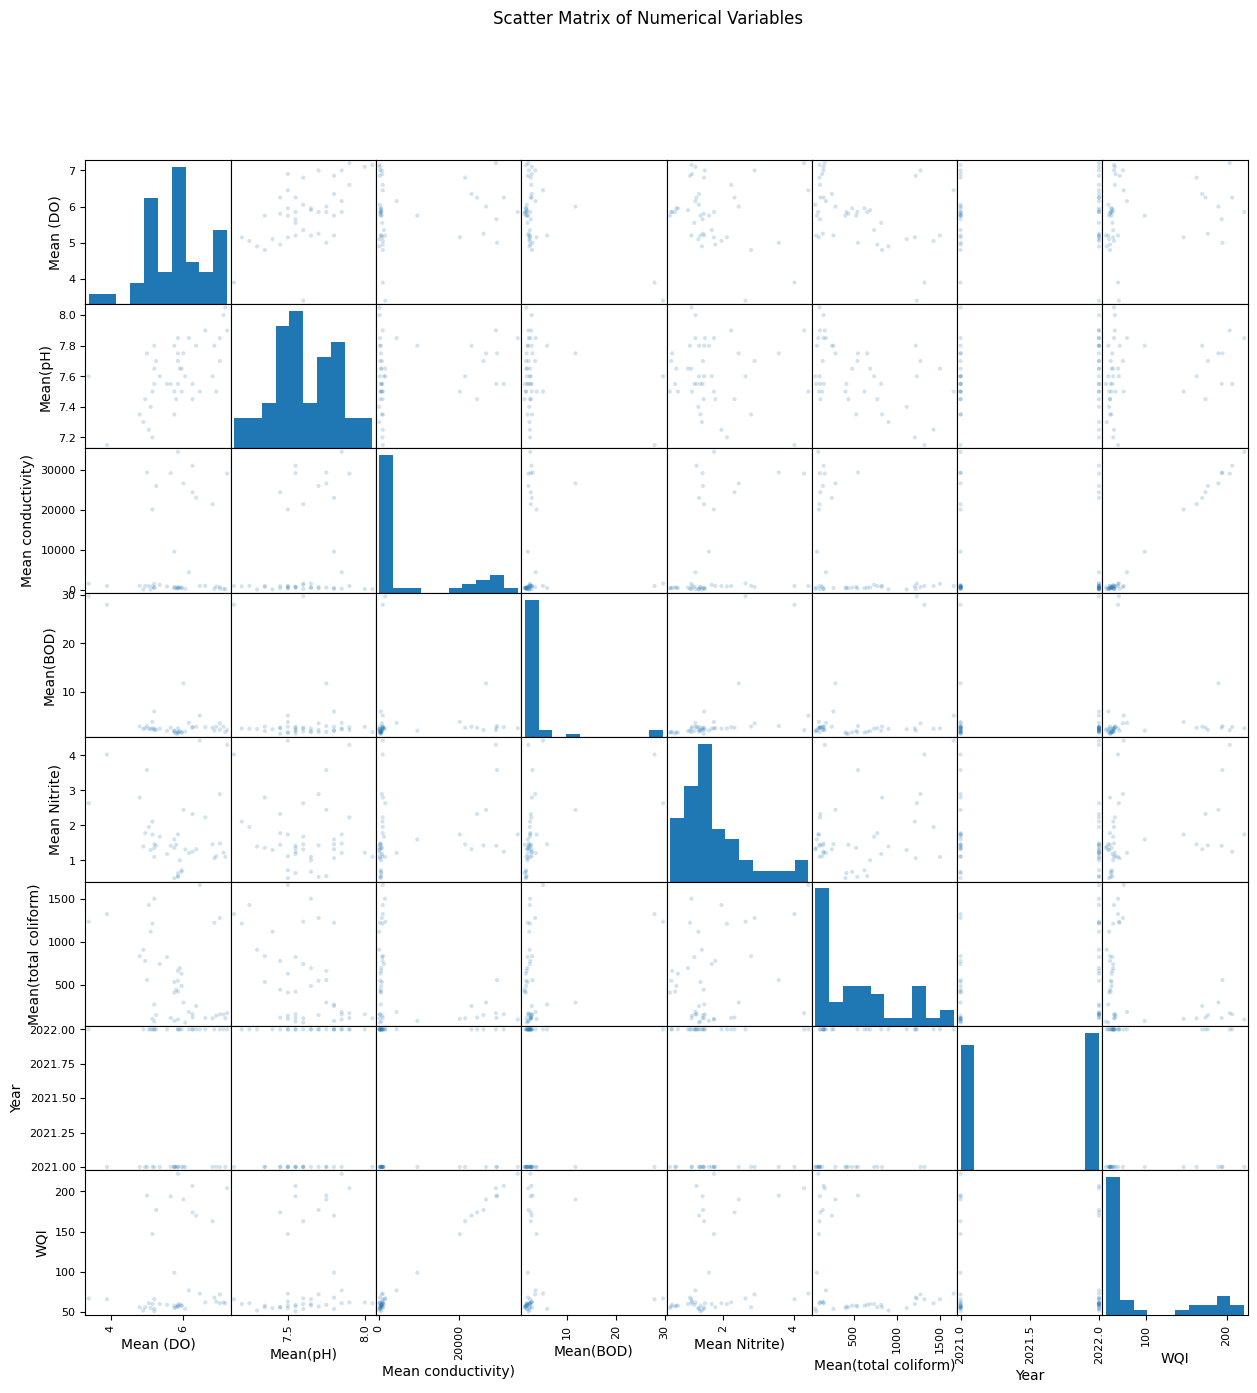

,Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform),Year,WQI
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,5.798864,7.611364,7545.875000,3.886364,1.702273,550.079545,2021.522727,92.636364
std,0.833073,0.207942,11563.839937,5.749018,0.956815,471.363188,0.505258,55.915672
min,3.400000,7.150000,176.500000,1.350000,0.495000,57.000000,2021.000000,51.000000
25%,5.200000,7.500000,532.250000,1.950000,1.168750,142.250000,2021.000000,57.750000
50%,5.850000,7.600000,977.250000,2.425000,1.425000,428.250000,2022.000000,61.500000
75%,6.275000,7.762500,12250.250000,2.800000,1.993750,822.500000,2022.000000,111.000000
max,7.200000,8.050000,34565.000000,29.700000,4.420000,1659.000000,2022.000000,222.000000


In [ ]:
import matplotlib.pyplot as plt

# Summarize numerical data to review key statistics
numerical_summary = df.describe()

# Plot pairwise relationships to check for linear trends with the target variable (WQI)
pd.plotting.scatter_matrix(df.select_dtypes(include=['float64', 'int64']), alpha=0.2, figsize=(15, 15), diagonal='hist')
plt.suptitle("Scatter Matrix of Numerical Variables")
plt.show()

numerical_summary

In [ ]:
from sklearn.preprocessing import StandardScaler

# Selecting numerical predictors and the target variable
predictor_columns = [ 'Mean (DO)', 'Mean(pH)', 'Mean conductivity)',
                     'Mean(BOD)', 'Mean Nitrite)',  'Mean(total coliform)']
target_column = 'WQI'

# Extract predictors and target
X = df[predictor_columns]
y = df[target_column]

# Scaling predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled predictors back to a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=predictor_columns)

# Display first few rows of scaled data
X_scaled_df.head()


,Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform)
0,0.062092,0.674414,-0.606287,-0.375901,-1.212916,0.232674
1,1.458483,1.160877,-0.628287,-0.296722,-0.229704,-0.854292
2,0.183518,-0.541742,-0.615953,-0.402294,-1.038476,0.162928
3,-0.727172,0.917645,-0.612716,0.363105,-0.250849,-0.606425
4,1.701334,1.404108,1.889060,-0.314317,2.746362,-0.823174


In [ ]:
#Variance inflation factor = to chack multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Variable"] = predictor_columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

vif_data



,Variable,VIF
0,Mean (DO),2.335658
1,Mean(pH),1.827260
2,Mean conductivity),1.679531
3,Mean(BOD),1.948711
4,Mean Nitrite),1.806367
5,Mean(total coliform),2.091626


In [ ]:
import statsmodels.api as sm

# Add a constant to the predictors for the regression model
X_with_const = sm.add_constant(X_scaled)

# Fit the regression model
model = sm.OLS(y, X_with_const).fit()

# Summarize the regression results
model_summary = model.summary()
model_summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    WQI   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.048e+05
Date:                Fri, 29 Nov 2024   Prob (F-statistic):           2.89e-85
Time:                        07:42:27   Log-Likelihood:                -1.1913
No. Observations:                  44   AIC:                             16.38
Df Residuals:                      37   BIC:                             28.87
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         92.6364      0.041   2266.527      0.000      92.554      92.719
x1             4.8873      0.062     78.242      0.000       4.761       5.014
x2             0.3975      0.055      7.195      0.000       0.286       0.509
x3            56.0617      0.053   1058.405      0.000      55.954      56.169
x4             2.7724      0.057     48.591      0.000       2.657       2.888
x5             0.0486      0.055      0.884      0.382      -0.063       0.160
x6             3.3592      0.059     56.830      0.000       3.239       3.479
==============================================================================
Omnibus:                        3.053   Durbin-Watson:                   1.973
Prob(Omnibus):                  0.217   Jarque-Bera (JB):                2.831
Skew:                           0.557   Prob(JB):                        0.243
Kurtosis:                       2.449   Cond. No.                         3.45
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

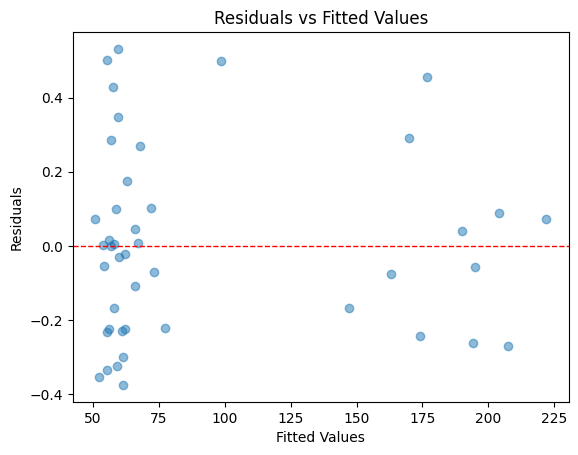

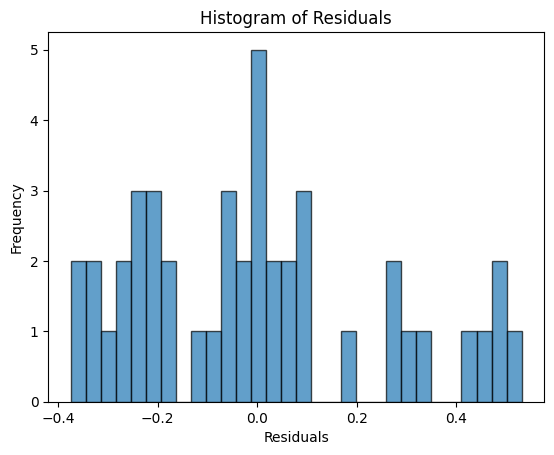

(ShapiroResult(statistic=0.9393745328724435, pvalue=0.02243748473888438),
 NormaltestResult(statistic=3.052644556807933, pvalue=0.21733349140418978))

In [ ]:
import numpy as np

# Extract residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

# Plot residuals vs fitted values to check homoscedasticity
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Plot histogram of residuals to check normality
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Perform statistical tests for normality
from scipy.stats import shapiro, normaltest

shapiro_test = shapiro(residuals)
normal_test = normaltest(residuals)

shapiro_test, normal_test


In [ ]:
# Calculate skewness for each predictor and the target variable
skewness = df[predictor_columns + [target_column]].skew()

# Select variables with high skewness (absolute skewness > 1)
high_skew_vars = skewness[abs(skewness) > 1].index.tolist()
skewness


,0
Mean (DO),-0.426423
Mean(pH),-0.113669
Mean conductivity),1.264648
Mean(BOD),4.029497
Mean Nitrite),1.425921
Mean(total coliform),0.805292
WQI,1.256675


In [ ]:
# Apply log transformation to highly skewed variables (adding 1 to avoid log(0))
transformed_df = df.copy()
for col in high_skew_vars:
    transformed_df[col] = np.log1p(transformed_df[col])

# Scale predictors after transformation
X_transformed = transformed_df[predictor_columns]
y_transformed = transformed_df[target_column]
X_scaled_transformed = scaler.fit_transform(X_transformed)

# Add constant for regression
X_transformed_const = sm.add_constant(X_scaled_transformed)

# Fit the regression model with transformed data
model_transformed = sm.OLS(y_transformed, X_transformed_const).fit()

# Summarize the transformed regression results
transformed_model_summary = model_transformed.summary()
transformed_model_summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    WQI   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     82.16
Date:                Fri, 29 Nov 2024   Prob (F-statistic):           7.16e-20
Time:                        07:42:46   Log-Likelihood:                 27.545
No. Observations:                  44   AIC:                            -41.09
Df Residuals:                      37   BIC:                            -28.60
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4021      0.021    206.957      0.000       4.359       4.445
x1             0.0761      0.031      2.426      0.020       0.013       0.140
x2             0.0104      0.029      0.360      0.721      -0.048       0.069
x3             0.4654      0.027     17.000      0.000       0.410       0.521
x4             0.0146      0.030      0.482      0.633      -0.047       0.076
x5             0.0014      0.030      0.048      0.962      -0.059       0.062
x6             0.0135      0.030      0.455      0.652      -0.047       0.074
==============================================================================
Omnibus:                        0.696   Durbin-Watson:                   1.909
Prob(Omnibus):                  0.706   Jarque-Bera (JB):                0.155
Skew:                           0.075   Prob(JB):                        0.925
Kurtosis:                       3.249   Cond. No.                         3.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""